# Introduction to Deep Learning, Assignment 2, Task 2

# Introduction


The goal of this assignment is to learn how to use encoder-decoder recurrent neural networks (RNNs). Specifically we will be dealing with a sequence to sequence problem and try to build recurrent models that can learn the principles behind simple arithmetic operations (**integer addition, subtraction and multiplication.**).

<img src="https://i.ibb.co/5Ky5pbk/Screenshot-2023-11-10-at-07-51-21.png" alt="Screenshot-2023-11-10-at-07-51-21" border="0" width="500"></a>

In this assignment you will be working with three different kinds of models, based on input/output data modalities:
1. **Text-to-text**: given a text query containing two integers and an operand between them (+ or -) the model's output should be a sequence of integers that match the actual arithmetic result of this operation
2. **Image-to-text**: same as above, except the query is specified as a sequence of images containing individual digits and an operand.
3. **Text-to-image**: the query is specified in text format as in the text-to-text model, however the model's output should be a sequence of images corresponding to the correct result.


### Description
Let us suppose that we want to develop a neural network that learns how to add or subtract
two integers that are at most two digits long. For example, given input strings of 5 characters: ‘81+24’ or
’41-89’ that consist of 2 two-digit long integers and an operand between them, the network should return a
sequence of 3 characters: ‘105 ’ or ’-48 ’ that represent the result of their respective queries. Additionally,
we want to build a model that generalizes well - if the network can extract the underlying principles behind
the ’+’ and ’-’ operands and associated operations, it should not need too many training examples to generate
valid answers to unseen queries. To represent such queries we need 13 unique characters: 10 for digits (0-9),
2 for the ’+’ and ’-’ operands and one for whitespaces ’ ’ used as padding.
The example above describes a text-to-text sequence mapping scenario. However, we can also use different
modalities of data to represent our queries or answers. For that purpose, the MNIST handwritten digit
dataset is going to be used again, however in a slightly different format. The functions below will be used to create our datasets.

---

*To work on this notebook you should create a copy of it.*

When using the Lab Computers, download the Jupyter Notebook to one of the machines first.

If you want to use Google Colab, you should first copy this notebook and enable GPU runtime in 'Runtime -> Change runtime type -> Hardware acceleration -> GPU **OR** TPU'.


# Function definitions for creating the datasets

First we need to create our datasets that are going to be used for training our models.

In order to create image queries of simple arithmetic operations such as '15+13' or '42-10' we need to create images of '+' and '-' signs using ***open-cv*** library. We will use these operand signs together with the MNIST dataset to represent the digits.

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import numpy as np
import tensorflow as tf
import random
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.layers import Dense, RNN, LSTM, Flatten, TimeDistributed, LSTMCell
from tensorflow.keras.layers import RepeatVector, Conv2D, SimpleRNN, GRU, Reshape, ConvLSTM2D, Conv2DTranspose,\
      GlobalAveragePooling2D, BatchNormalization, MaxPooling2D, Dropout, GlobalMaxPooling2D
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.activations import gelu
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

2025-11-13 18:25:26.844200: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-13 18:25:29.794975: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763054730.018741 1871001 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763054730.089557 1871001 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763054731.992327 1871001 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

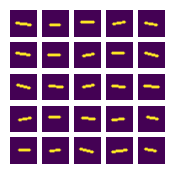

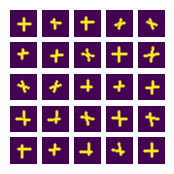

In [3]:
from scipy.ndimage import rotate


# Create plus/minus operand signs
def generate_images(number_of_images=50, sign='-'):
    blank_images = np.zeros([number_of_images, 28, 28])  # Dimensionality matches the size of MNIST images (28x28)
    x = np.random.randint(12, 16, (number_of_images, 2)) # Randomized x coordinates
    y1 = np.random.randint(6, 10, number_of_images)       # Randomized y coordinates
    y2 = np.random.randint(18, 22, number_of_images)     # -||-

    for i in range(number_of_images): # Generate n different images
        cv2.line(blank_images[i], (y1[i], x[i,0]), (y2[i], x[i, 1]), (255,0,0), 2, cv2.LINE_AA)     # Draw lines with randomized coordinates
        if sign == '+':
            cv2.line(blank_images[i], (x[i,0], y1[i]), (x[i, 1], y2[i]), (255,0,0), 2, cv2.LINE_AA) # Draw lines with randomized coordinates

    return blank_images

def show_generated(images, n=5):
    plt.figure(figsize=(2, 2))
    for i in range(n**2):
        plt.subplot(n, n, i+1)
        plt.axis('off')
        plt.imshow(images[i])
    plt.show()

show_generated(generate_images())
show_generated(generate_images(sign='+'))

In [4]:
def create_data(highest_integer, num_addends=2, operands=['+', '-']):
    """
    Creates the following data for all pairs of integers up to [1:highest integer][+/-][1:highest_integer]:

    @return:
    X_text: '51+21' -> text query of an arithmetic operation (5)
    X_img : Stack of MNIST images corresponding to the query (5 x 28 x 28) -> sequence of 5 images of size 28x28
    y_text: '72' -> answer of the arithmetic text query
    y_img :  Stack of MNIST images corresponding to the answer (3 x 28 x 28)

    Images for digits are picked randomly from the whole MNIST dataset.
    """

    num_indices = [np.where(MNIST_labels==x) for x in range(10)]
    num_data = [MNIST_data[inds] for inds in num_indices]
    image_mapping = dict(zip(unique_characters[:10], num_data))
    image_mapping['-'] = generate_images()
    image_mapping['+'] = generate_images(sign='+')
    image_mapping['*'] = generate_images(sign='*')
    image_mapping[' '] = np.zeros([1, 28, 28])

    X_text, X_img, y_text, y_img = [], [], [], []

    for i in range(highest_integer + 1):      # First addend
        for j in range(highest_integer + 1):  # Second addend
            for sign in operands: # Create all possible combinations of operands
                query_string = to_padded_chars(str(i) + sign + str(j), max_len=max_query_length, pad_right=True)
                query_image = []
                for n, char in enumerate(query_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    query_image.append(image_set[index].squeeze())

                result = eval(query_string)
                result_string = to_padded_chars(result, max_len=max_answer_length, pad_right=True)
                result_image = []
                for n, char in enumerate(result_string):
                    image_set = image_mapping[char]
                    index = np.random.randint(0, len(image_set), 1)
                    result_image.append(image_set[index].squeeze())

                X_text.append(query_string)
                X_img.append(np.stack(query_image))
                y_text.append(result_string)
                y_img.append(np.stack(result_image))

    return np.stack(X_text), np.stack(X_img)/255., np.stack(y_text), np.stack(y_img)/255.

def to_padded_chars(integer, max_len=3, pad_right=False):
    """
    Returns a string of len()=max_len, containing the integer padded with ' ' on either right or left side
    """
    length = len(str(integer))
    padding = (max_len - length) * ' '
    if pad_right:
        return str(integer) + padding
    else:
        return padding + str(integer)


# Creating our data

The dataset consists of 20000 samples that (additions and subtractions between all 2-digit integers) and they have two kinds of inputs and label modalities:

  **X_text**: strings containing queries of length 5: ['  1+1  ', '11-18', ...]

  **X_image**: a stack of images representing a single query, dimensions: [5, 28, 28]

  **y_text**: strings containing answers of length 3: ['  2', '156']

  **y_image**: a stack of images that represents the answer to a query, dimensions: [3, 28, 28]

(20000,) (20000, 5, 28, 28) (20000,) (20000, 3, 28, 28)
Query #2228

X_text: "11+14" = y_text: "25 "


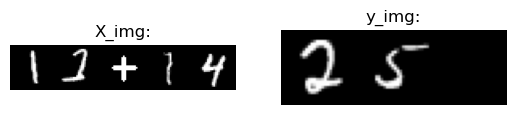

Query #4495

X_text: "22-47" = y_text: "-25"


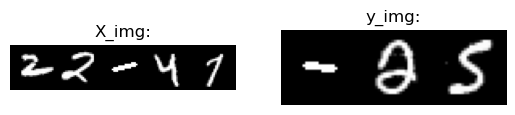

Query #5410

X_text: "27+5 " = y_text: "32 "


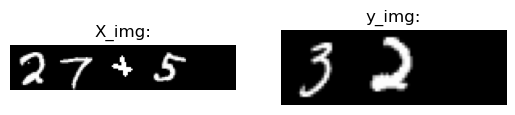

Query #4203

X_text: "21-1 " = y_text: "20 "


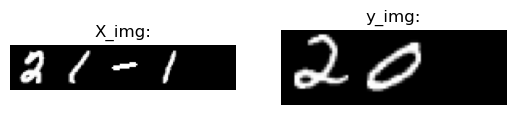

Query #5270

X_text: "26+35" = y_text: "61 "


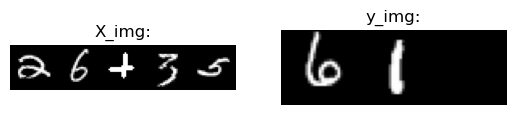

Query #3535

X_text: "17-67" = y_text: "-50"


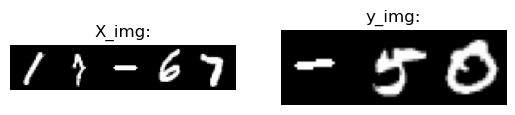

Query #2278

X_text: "11+39" = y_text: "50 "


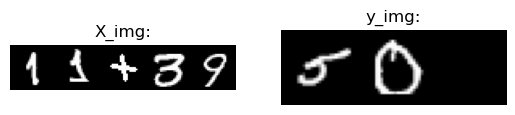

Query #8771

X_text: "43-85" = y_text: "-42"


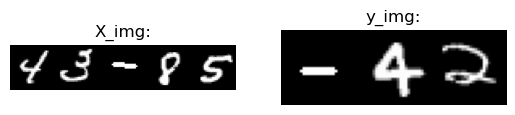

Query #7976

X_text: "39+88" = y_text: "127"


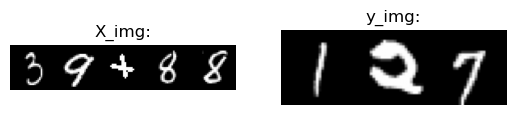

Query #4663

X_text: "23-31" = y_text: "-8 "


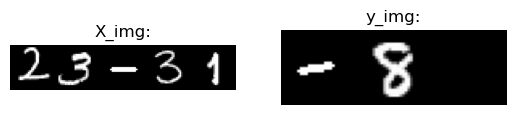

In [5]:
# Illustrate the generated query/answer pairs

unique_characters = '0123456789+- '       # All unique characters that are used in the queries (13 in total: digits 0-9, 2 operands [+, -], and a space character ' '.)
highest_integer = 99                      # Highest value of integers contained in the queries

max_int_length = len(str(highest_integer))# Maximum number of characters in an integer
max_query_length = max_int_length * 2 + 1 # Maximum length of the query string (consists of two integers and an operand [e.g. '22+10'])
max_answer_length = 3    # Maximum length of the answer string (the longest resulting query string is ' 1-99'='-98')

# Create the data (might take around a minute)
(MNIST_data, MNIST_labels), _ = tf.keras.datasets.mnist.load_data()
X_text, X_img, y_text, y_img = create_data(highest_integer)
print(X_text.shape, X_img.shape, y_text.shape, y_img.shape)


## Display the samples that were created
def display_sample(n):
    labels = ['X_img:', 'y_img:']
    for i, data in enumerate([X_img, y_img]):
        plt.subplot(1,2,i+1)
        # plt.set_figheight(15)
        plt.axis('off')
        plt.title(labels[i])
        plt.imshow(np.hstack(data[n]), cmap='gray')
    print('='*50, f'\nQuery #{n}\n\nX_text: "{X_text[n]}" = y_text: "{y_text[n]}"')
    plt.show()

for _ in range(10):
    display_sample(np.random.randint(0, 10000, 1)[0])

## Helper functions

The functions below will help with input/output of the data.

In [6]:
# One-hot encoding/decoding the text queries/answers so that they can be processed using RNNs
# You should use these functions to convert your strings and read out the output of your networks

def encode_labels(labels, max_len=3):
  n = len(labels)
  length = len(labels[0])
  char_map = dict(zip(unique_characters, range(len(unique_characters))))
  one_hot = np.zeros([n, length, len(unique_characters)])
  for i, label in enumerate(labels):
      m = np.zeros([length, len(unique_characters)])
      for j, char in enumerate(label):
          m[j, char_map[char]] = 1
      one_hot[i] = m

  return one_hot


def decode_labels(labels):
    pred = np.argmax(labels, axis=2)
    predicted = [''.join([unique_characters[i] for i in j]) for j in pred]

    return predicted

X_text_onehot = encode_labels(X_text)
y_text_onehot = encode_labels(y_text)

print(X_text_onehot.shape, y_text_onehot.shape)

(20000, 5, 13) (20000, 3, 13)


---
---

## I. Text-to-text RNN model

The following code showcases how Recurrent Neural Networks (RNNs) are built using Keras. Several new layers are going to be used:

1. LSTM
2. TimeDistributed
3. RepeatVector

The code cell below explains each of these new components.

<img src="https://i.ibb.co/NY7FFTc/Screenshot-2023-11-10-at-09-27-25.png" alt="Screenshot-2023-11-10-at-09-27-25" border="0" width="500"></a>


In [8]:
def build_text2text_model():

    # We start by initializing a sequential model
    text2text = tf.keras.Sequential()

    # "Encode" the input sequence using an RNN, producing an output of size 256.
    # In this case the size of our input vectors is [5, 13] as we have queries of length 5 and 13 unique characters. Each of these 5 elements in the query will be fed to the network one by one,
    # as shown in the image above (except with 5 elements).
    # Hint: In other applications, where your input sequences have a variable length (e.g. sentences), you would use input_shape=(None, unique_characters).
    text2text.add(LSTM(256, input_shape=(None, len(unique_characters))))

    # As the decoder RNN's input, repeatedly provide with the last output of RNN for each time step. Repeat 3 times as that's the maximum length of the output (e.g. '  1-99' = '-98')
    # when using 2-digit integers in queries. In other words, the RNN will always produce 3 characters as its output.
    text2text.add(RepeatVector(max_answer_length))

    # By setting return_sequences to True, return not only the last output but all the outputs so far in the form of (num_samples, timesteps, output_dim). This is necessary as TimeDistributed in the below expects
    # the first dimension to be the timesteps.
    text2text.add(LSTM(256, return_sequences=True))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    text2text.add(TimeDistributed(Dense(len(unique_characters), activation='softmax')))

    # Next we compile the model using categorical crossentropy as our loss function.
    text2text.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    text2text.summary()

    return text2text

In [ ]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
SEED = 69
N_EPOCHS = 200
BATCH_SIZE = 64

test_split = [0.5, 0.75, 0.9]
for split in test_split:
    X_train, X_test, y_train, y_test= train_test_split(X_text_onehot, y_text_onehot, test_size=split, random_state=SEED)

    
    train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    test_ds = (tf.data.Dataset.from_tensor_slices((X_test, y_test))).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    model_filepath = f'.text_2_text_{split}.model.keras'
    callback = [ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5), 
                EarlyStopping(patience=17), 
                ModelCheckpoint(filepath=model_filepath, monitor='val_loss', save_best_only=True, mode='min')]


    model = build_text2text_model()
    history = model.fit(train_ds, epochs=N_EPOCHS, validation_data=test_ds, callbacks=callback)
    hist_df = pd.DataFrame(history.history).to_csv(f".text_2_text_{split}_history.csv")




/vol/home/s2631415/.conda/envs/idl2/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_5 (RepeatVector)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,133 (3.07 MB)

 Trainable params: 805,133 (3.07 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                  │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_7 (RepeatVector)  │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 805,133 (3.07 MB)

 Trainable params: 805,133 (3.07 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.2122 - loss: 2.3774 - val_accuracy: 0.3004 - val_loss: 2.2323 - learning_rate: 0.0010
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.3328 - loss: 2.1197 - val_accuracy: 0.3856 - val_loss: 1.9984 - learning_rate: 0.0010
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3900 - loss: 1.9109 - val_accuracy: 0.3908 - val_loss: 1.8457 - learning_rate: 0.0010
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4005 - loss: 1.8015 - val_accuracy: 0.3983 - val_loss: 1.7797 - learning_rate: 0.0010
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4035 - loss: 1.7528 - val_accuracy: 0.3825 - val_loss: 1.8050 - learning_rate: 0.0010
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4052 - loss: 1.7118 - val_accuracy: 0.4080 - val_loss: 1.7007 - learning_rate: 0.0010
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.4170 - loss: 1.6573 - 


---
---

## II. Image to text RNN Model

Hint: There are two ways of building the encoder for such a model - again by using the regular LSTM cells (with flattened images as input vectors) or recurrect convolutional layers [ConvLSTM2D](https://keras.io/api/layers/recurrent_layers/conv_lstm2d/).

The goal here is to use **X_img** as inputs and **y_text** as outputs.

### Model using ConvLSTM2D 

Model has a strong tendancy to overfit so will compare it against other model

In [6]:
"""This model has a strong tendancy to overfit so it is kept and used to demonstrate this"""

## Your code
def build_image2text_model():

    # We start by initializing a sequential model
    image2text = tf.keras.Sequential()
    image2text.add(tf.keras.layers.Input(shape=(5, 28, 28, 1)))
    image2text.add(BatchNormalization())

    # Single ConvLSTM with moderate filters
    image2text.add(ConvLSTM2D(filters=len(unique_characters), 
                            kernel_size=(4, 4),
                            padding='same',
                            activation='gelu',
                            kernel_regularizer=tf.keras.regularizers.l2(0.01),
                            dropout=0.3,
                            recurrent_dropout=0.3,
                            return_sequences=True))

    # Normalize more
    image2text.add(BatchNormalization())
    
    # Global average to (batch, 32)
    image2text.add(TimeDistributed(GlobalAveragePooling2D(data_format='channels_last', keepdims=False)))

    image2text.add(LSTM(256))

    # Apply a dense layer to the every temporal slice of an input. For each of step of the output sequence, decide which character should be chosen.
    image2text.add(RepeatVector(max_answer_length))   # Repeat context 3 times → (batch, 3, 32)
    image2text.add(LSTM(256, return_sequences=True))  # Generate a sequence
    image2text.add(Dropout(0.5))
    image2text.add(TimeDistributed(Dense((len(unique_characters)), activation='softmax')))
    
    # Next we compile the model using categorical crossentropy as our loss function.
    image2text.compile(loss='categorical_crossentropy', optimizer='adamW', metrics=['accuracy'])
    image2text.summary()

    return image2text




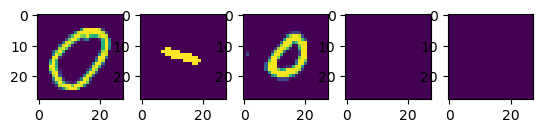

In [7]:
# Some plotting to understand the structure of the data
fig, ax = plt.subplots(1,5)
ax[0].imshow(X_img[1][0])
ax[1].imshow(X_img[1][1])
ax[2].imshow(X_img[1][2])
ax[3].imshow(X_img[1][3])
ax[4].imshow(X_img[1][4])


In [7]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
SEED = 191918173
N_EPOCHS = 300
BATCH_SIZE = 32


def augment_sequence_consistent(seq, label):
    """Apply consistent augmentation to all frames in a sequence"""
    # Random flip with same decision for all frames in sequence
    seq = tf.cast(seq, dtype=tf.float32)
    if tf.random.uniform(()) > 0.5:
        # Apply flip to each frame in the sequence
        seq = tf.map_fn(lambda frame: tf.image.flip_left_right(frame), seq)
    
    # Random brightness adjustment (consistent for all frames)
    delta = tf.random.uniform((), 0, 0.2)
    seq = seq + delta

    
    # Ensure values stay in valid range
    seq = tf.clip_by_value(seq, 0.0, 1.0)
    
    return seq, label

Xi = np.expand_dims(X_img, axis=-1)
test_split = [0.2, 0.5, 0.75, 0.9]
for split in test_split:
    X_train, X_test, y_train, y_test= train_test_split(Xi, y_text_onehot, test_size=split, random_state=SEED)


    train_ds = (
            tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(1000).batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
            .map(augment_sequence_consistent)
                )
    
    test_ds = (
            tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .shuffle(1000)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

    model_filepath = f'image_2_text_{split}.model.keras'
    callback = [ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5), 
                EarlyStopping(patience=17), 
                ModelCheckpoint(filepath=model_filepath, monitor='val_loss', save_best_only=True, mode='min')]


    model = build_image2text_model()
    history = model.fit(train_ds, epochs=N_EPOCHS, validation_data=test_ds, callbacks=callback)
    hist_df = pd.DataFrame(history.history).to_csv(f"image_2_text_{split}_history.csv")




I0000 00:00:1762977761.995105 1266306 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ batch_normalization             │ (None, 5, 28, 28, 1)   │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 5, 28, 28, 13)  │        11,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 28, 28, 13)  │            52 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 5, 13)          │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 256)            │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3, 256)         │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 3, 13)          │         3,341 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 816,889 (3.12 MB)

 Trainable params: 816,861 (3.12 MB)

...

 Trainable params: 816,861 (3.12 MB)

 Non-trainable params: 28 (112.00 B)

Epoch 1/300


E0000 00:00:1762978454.456620 1266306 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: MutableGraphView::SortTopologically error: detected edge(s) creating cycle(s) {'Func/StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/input/_902' -> 'StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/sequential_3_1/conv_lstm2d_3_1/while/conv_lstm_cell_1/mul_7', 'Func/StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/input/_903' -> 'StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/sequential_3_1/conv_lstm2d_3_1/while/conv_lstm_cell_1/mul_8', 'StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/sequential_3_1/conv_lstm2d_3_1/while/conv_lstm_cell_1/Gelu_1/mul_2' -> 'StatefulPartitionedCall/sequential_3_1/conv_lstm2d_3_1/while/body/_63/sequential_3_1/conv_lstm2d_3_1/while/conv_lstm_cell_1/mul_10'}.


63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.2508 - loss: 2.3380 - val_accuracy: 0.3287 - val_loss: 2.2364 - learning_rate: 0.0010
Epoch 2/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.3292 - loss: 2.1115 - val_accuracy: 0.3287 - val_loss: 2.1720 - learning_rate: 0.0010
Epoch 3/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.3410 - loss: 2.0661 - val_accuracy: 0.3139 - val_loss: 2.0775 - learning_rate: 0.0010
Epoch 4/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.3625 - loss: 2.0330 - val_accuracy: 0.3110 - val_loss: 2.0810 - learning_rate: 0.0010
Epoch 5/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.3738 - loss: 1.9949 - val_accuracy: 0.2924 - val_loss: 2.1646 - learning_rate: 0.0010
Epoch 6/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 109ms/step - accuracy: 0.3768 - loss: 1.9702 - val_accuracy: 0.2948 - val_loss: 2.1425 - learning_rate: 0.0010
Epoch 7/300
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.3762 - loss: 1.9567 - val_

### Seperate Convolutional block 

This model is different from the previous one as it uses a convolutional block which is applied over each timestep to convert the image to a onehot encoding, which is then red by a LSTM to evaluate further.

In [15]:
def final3_accuracy(y_true, y_pred):
    """
    Computes categorical accuracy only on the last 3 time steps.
    y_true, y_pred: shape (batch, 8, 13)
    """
    # Extract last 3 time steps
    y_true_last3 = y_true[:, -3:, :]   # (batch, 3, 13)
    y_pred_last3 = y_pred[:, -3:, :]   # (batch, 3, 13)
    
    # Compute per-timestep categorical accuracy
    acc = tf.keras.metrics.categorical_accuracy(y_true_last3, y_pred_last3)  # (batch, 3)
    
    # Return mean accuracy across all time steps and batches
    return tf.reduce_mean(acc)

class ConvBlock(tf.keras.layers.Layer):
    """This class is used to convert the X_img -> X_text"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.model = tf.keras.Sequential([
            BatchNormalization(),
            Conv2D(16, (5, 5), padding='same', activation='relu', kernel_regularizer='l2'),
            Conv2D(16, (4, 4), padding='same', activation='relu', kernel_regularizer='l2'),
            MaxPooling2D((2,2)),
            BatchNormalization(),

            Conv2D(32, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            Conv2D(32, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            MaxPooling2D((2,2)),
            BatchNormalization(),

            Conv2D(64, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            Conv2D(64, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            MaxPooling2D((2,2)),
            BatchNormalization(),

            Conv2D(128, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            Conv2D(128, (3, 3), padding='same', activation='gelu', kernel_regularizer='l2'),
            GlobalAveragePooling2D(),
            BatchNormalization(),

            Dense(64, activation='relu'),
            Dense(13, activation='softmax')
        ])
        
    def call(self, x):
        return self.model(x)


class LSTMBlock(tf.keras.layers.Layer):
    """This class is used to convert X_text -> y_text"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.model = tf.keras.Sequential([
            LSTM(256), 
            RepeatVector(3),
            LSTM(256, return_sequences=True),
            Dense((13), activation='softmax')
        ])

    def call(self, x):
        return self.model(x)  
    

class Image2TextBlock(tf.keras.layers.Layer):
    """This class is used to combine ConvBlock and LSTMBlock. The final output of this class is the concatenated output of the ConvBlock and LSTMBlock. This allows for a skip connection for the ConvBlock"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.conv = ConvBlock()
        self.LSTM = LSTMBlock()
    
    def call(self, x):
        x_text = TimeDistributed(self.conv)(x)
        y_text = self.LSTM(x_text)
        out = tf.concat([x_text, y_text], axis=1)
        return out

def LSTM_image2text_model():

    # We start by initializing a sequential model
    inputs = tf.keras.layers.Input(shape=(5, 28, 28, 1))
    outputs = Image2TextBlock()(inputs)
    model = tf.keras.Model(inputs, outputs)
    # Next we compile the model using categorical crossentropy as our loss function.
    model.compile(loss='categorical_crossentropy',
                  optimizer='adamW',
                  metrics=['accuracy', final3_accuracy])
    return model


In [23]:
## Your code (look at the assignment description for your tasks for text-to-text model):
## Your first task is to fit the text2text model using X_text and y_text)
SEED = 191918173
N_EPOCHS = 150
BATCH_SIZE = 32


def augment_sequence_consistent(seq, label):
    """Apply consistent augmentation to all frames in a sequence"""
    # Random flip with same decision for all frames in sequence
    seq = tf.cast(seq, dtype=tf.float32)
    if tf.random.uniform(()) > 0.5:
        # Apply flip to each frame in the sequence
        seq = tf.map_fn(lambda frame: tf.image.flip_left_right(frame), seq)
    
    # Random brightness adjustment (consistent for all frames)
    delta = tf.random.uniform((), 0, 0.2)
    seq = seq + delta

    
    # Ensure values stay in valid range
    seq = tf.clip_by_value(seq, 0.0, 1.0)
    
    return seq, label

Xi = np.expand_dims(X_img, axis=-1)
test_split = [0.5, 0.75, 0.9]
y_concat = np.concatenate((X_text_onehot, y_text_onehot), axis=1,)
print(y_concat.shape)
for split in test_split:
    X_train, X_test, y_train, y_test= train_test_split(Xi, y_concat, test_size=split, random_state=SEED)


    train_ds = (
            tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(1000).batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE)
            .map(augment_sequence_consistent)
                )
    
    test_ds = (
            tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))

    model_filepath = f'I2T_{split}_double.model.keras'
    callback = [ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10), 
                EarlyStopping(patience=33), 
                ModelCheckpoint(filepath=model_filepath, monitor='val_loss', save_best_only=True, mode='min')]


    model = LSTM_image2text_model()
    history = model.fit(train_ds, epochs=N_EPOCHS, validation_data=test_ds, callbacks=callback)
    hist_df = pd.DataFrame(history.history).to_csv(f"I2T_{split}_double_history.csv")




(20000, 8, 13)


/vol/home/s2631415/.conda/envs/idl2/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'conv_block_3', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/150


I0000 00:00:1763055848.171277 1897617 cuda_dnn.cc:529] Loaded cuDNN version 90101


313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.7133 - final3_accuracy: 0.3617 - loss: 2.1343 - val_accuracy: 0.6353 - val_final3_accuracy: 0.3626 - val_loss: 1.4874 - learning_rate: 0.0010
Epoch 2/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7569 - final3_accuracy: 0.4344 - loss: 0.9892 - val_accuracy: 0.7628 - val_final3_accuracy: 0.4511 - val_loss: 0.9605 - learning_rate: 0.0010
Epoch 3/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7795 - final3_accuracy: 0.4758 - loss: 0.8319 - val_accuracy: 0.6893 - val_final3_accuracy: 0.4417 - val_loss: 1.0907 - learning_rate: 0.0010
Epoch 4/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7890 - final3_accuracy: 0.4979 - loss: 0.7977 - val_accuracy: 0.7835 - val_final3_accuracy: 0.5052 - val_loss: 0.8263 - learning_rate: 0.0010
Epoch 5/150
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8012 - final3_accuracy: 0.5252 - loss: 0.7396 - val_accuracy: 0.8084 - val_final3_accuracy: 0.5288 

/vol/home/s2631415/.conda/envs/idl2/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'conv_block_4', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.6792 - final3_accuracy: 0.3302 - loss: 3.1026 - val_accuracy: 0.6725 - val_final3_accuracy: 0.3846 - val_loss: 1.8803 - learning_rate: 0.0010
Epoch 2/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.7416 - final3_accuracy: 0.3959 - loss: 1.3378 - val_accuracy: 0.4855 - val_final3_accuracy: 0.3244 - val_loss: 2.4118 - learning_rate: 0.0010
Epoch 3/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.7488 - final3_accuracy: 0.4161 - loss: 1.0809 - val_accuracy: 0.7054 - val_final3_accuracy: 0.4095 - val_loss: 1.1535 - learning_rate: 0.0010
Epoch 4/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.7693 - final3_accuracy: 0.4461 - loss: 0.8860 - val_accuracy: 0.7026 - val_final3_accuracy: 0.4327 - val_loss: 1.1368 - learning_rate: 0.0010
Epoch 5/150
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 74ms/step - accuracy: 0.7762 - final3_accuracy: 0.4698 - loss: 0.8435 - val_accuracy: 0.7462 - val_final3_accur

/vol/home/s2631415/.conda/envs/idl2/lib/python3.12/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'conv_block_5', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Epoch 1/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 152ms/step - accuracy: 0.6292 - final3_accuracy: 0.2697 - loss: 4.2295 - val_accuracy: 0.2080 - val_final3_accuracy: 0.3287 - val_loss: 4.3428 - learning_rate: 0.0010
Epoch 2/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.7289 - final3_accuracy: 0.3725 - loss: 2.3619 - val_accuracy: 0.6827 - val_final3_accuracy: 0.3836 - val_loss: 2.1119 - learning_rate: 0.0010
Epoch 3/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - accuracy: 0.7377 - final3_accuracy: 0.3867 - loss: 1.6299 - val_accuracy: 0.7054 - val_final3_accuracy: 0.3854 - val_loss: 1.5590 - learning_rate: 0.0010
Epoch 4/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.7431 - final3_accuracy: 0.3932 - loss: 1.3133 - val_accuracy: 0.7209 - val_final3_accuracy: 0.3979 - val_loss: 1.3095 - learning_rate: 0.0010
Epoch 5/150
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.7481 - final3_accuracy: 0.4033 - loss: 1.1518 - val_accuracy: 0.7423 - val_final3_accuracy: 0.38

---
---

## III. Text to image RNN Model

Hint: to make this model work really well you could use deconvolutional layers in your decoder (you might need to look up ***Conv2DTranspose*** layer). However, regular vector-based decoder will work as well.

The goal here is to use **X_text** as inputs and **y_img** as outputs.

In [ ]:
# Your code




